In [17]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[0]))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from config import PROCESSED_DATA_DIR

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

In [3]:
pokemon_clean = pd.read_parquet(PROCESSED_DATA_DIR / "pokemon_data_clean.parquet")
pokemon_features = pd.read_parquet(PROCESSED_DATA_DIR / "pokemon_data_features.parquet")

In [4]:
print("Clean shape:", pokemon_clean.shape)
print("Feature shape:", pokemon_features.shape)

Clean shape: (1045, 34)
Feature shape: (1045, 47)


## Target Overview

In [5]:
pokemon_clean["total_points"].describe()

count    1045.000000
mean      439.353110
std       121.992897
min       175.000000
25%       330.000000
50%       458.000000
75%       515.000000
max      1125.000000
Name: total_points, dtype: float64

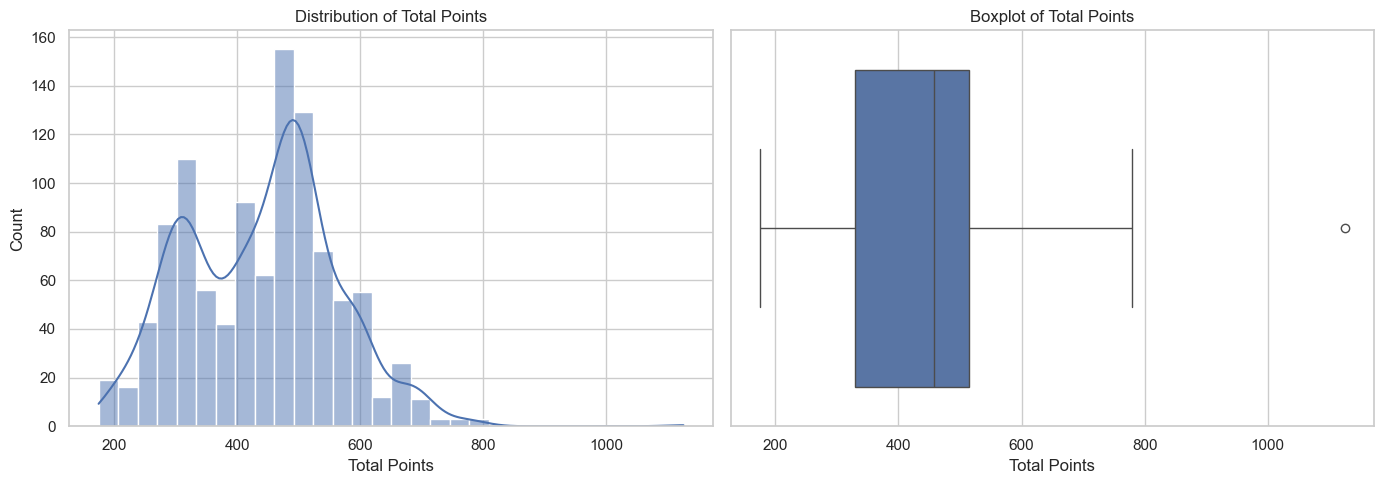

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(pokemon_clean["total_points"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total Points")
axes[0].set_xlabel("Total Points")

sns.boxplot(x=pokemon_clean["total_points"], ax=axes[1])
axes[1].set_title("Boxplot of Total Points")
axes[1].set_xlabel("Total Points")

plt.tight_layout()

## Numeric Relationships

In [7]:
numeric_cols = ["total_points", "generation", "height_m", "weight_kg", "catch_rate", "base_friendship"]
pokemon_clean[numeric_cols].corr(numeric_only=True)[["total_points"]].sort_values("total_points", ascending=False)

,total_points
total_points,1.000000
weight_kg,0.468180
height_m,0.374311
generation,0.091050
base_friendship,-0.300789
catch_rate,-0.712485


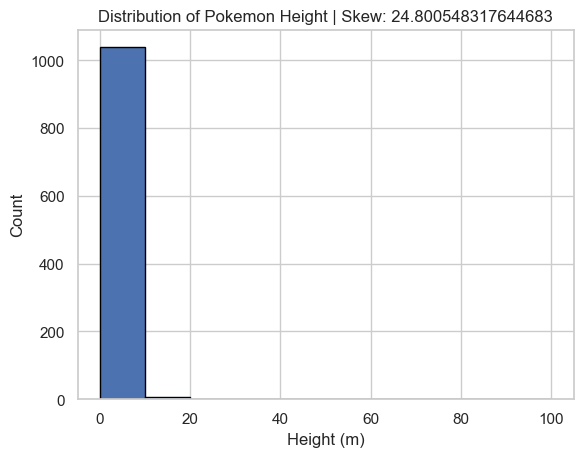

In [8]:
skew = pokemon_clean["height_m"].skew()

plt.hist(pokemon_clean["height_m"], edgecolor="black")
plt.title(f"Distribution of Pokemon Height | Skew: {skew}")
plt.xlabel("Height (m)")
plt.ylabel("Count")
plt.show()

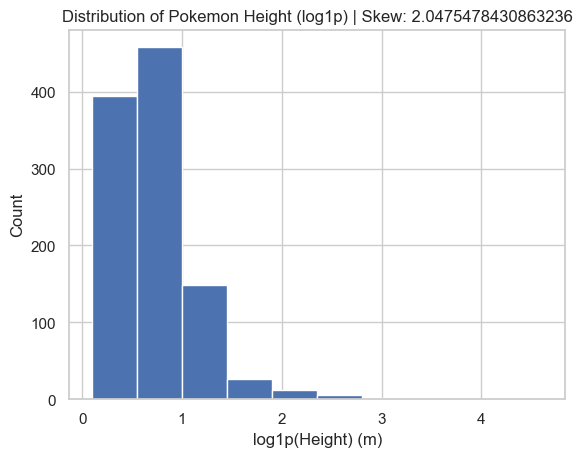

In [18]:
pokemon_clean["height_m_log"] = np.log1p(pokemon_clean["height_m"])
skew = pokemon_clean["height_m_log"].skew()

plt.hist(pokemon_clean["height_m_log"])
plt.title(f"Distribution of Pokemon Height (log1p) | Skew: {skew}")
plt.xlabel("log1p(Height) (m)")
plt.ylabel("Count")
plt.show()

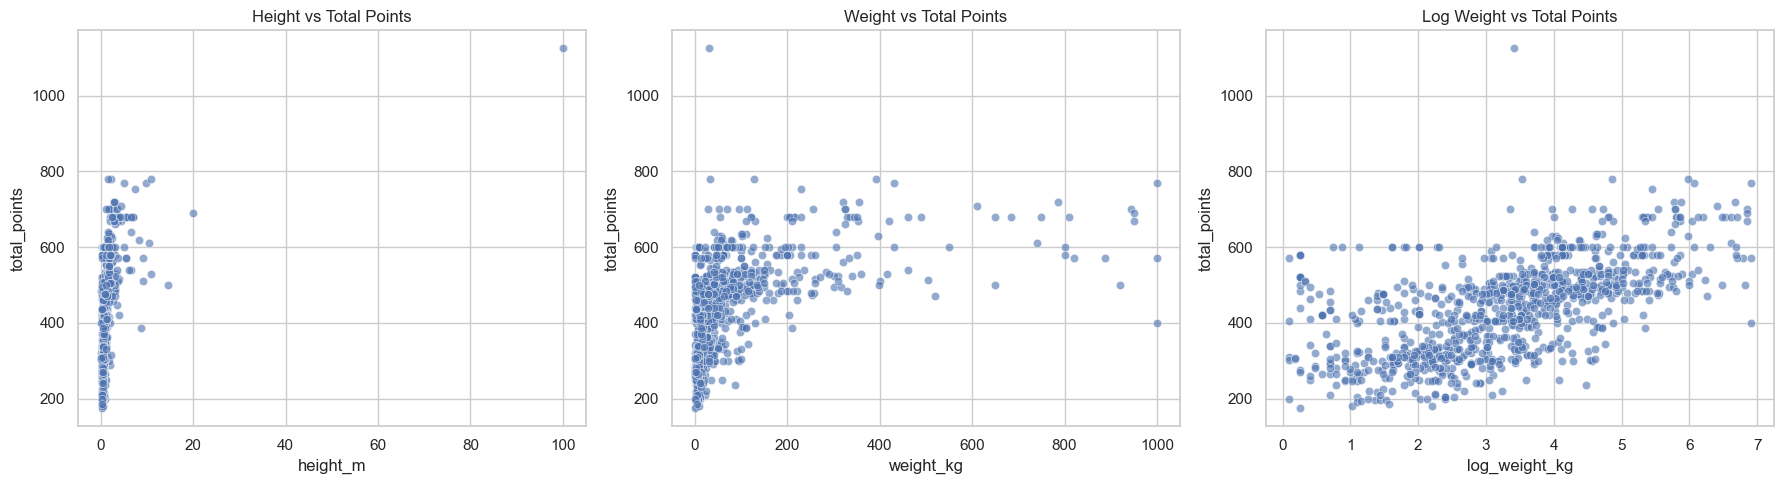

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=pokemon_clean, x="height_m", y="total_points", alpha=0.6, ax=axes[0])
axes[0].set_title("Height vs Total Points")

sns.scatterplot(data=pokemon_clean, x="weight_kg", y="total_points", alpha=0.6, ax=axes[1])
axes[1].set_title("Weight vs Total Points")

sns.scatterplot(data=pokemon_features, x="log_weight_kg", y="total_points", alpha=0.6, ax=axes[2])
axes[2].set_title("Log Weight vs Total Points")

plt.tight_layout()

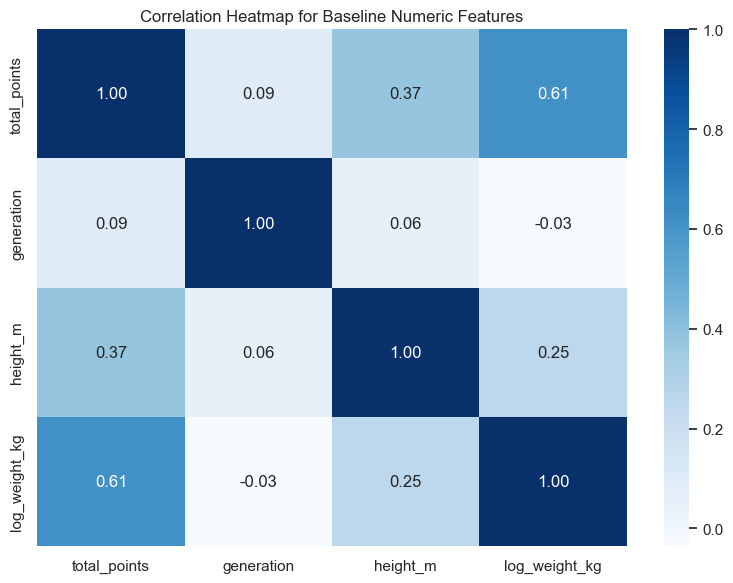

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pokemon_features[["total_points", "generation", "height_m", "log_weight_kg"]].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("Correlation Heatmap for Baseline Numeric Features")
plt.tight_layout()

## Categorical Summaries

In [11]:
pokemon_clean.groupby("status")["total_points"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

,count,mean,median
status,,,
legendary,42,675.309524,680.0
mythical,30,594.666667,600.0
sub legendary,55,576.527273,580.0
normal,918,415.263617,430.0


In [12]:
top_type_1 = (
    pokemon_clean.groupby("type_1")["total_points"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)
top_type_1

,count,mean
type_1,,
dragon,41,536.365854
psychic,81,489.370370
steel,36,481.472222
fire,65,455.015385
electric,62,451.435484
rock,60,448.683333
fighting,42,446.404762
ghost,42,444.071429
flying,8,440.000000


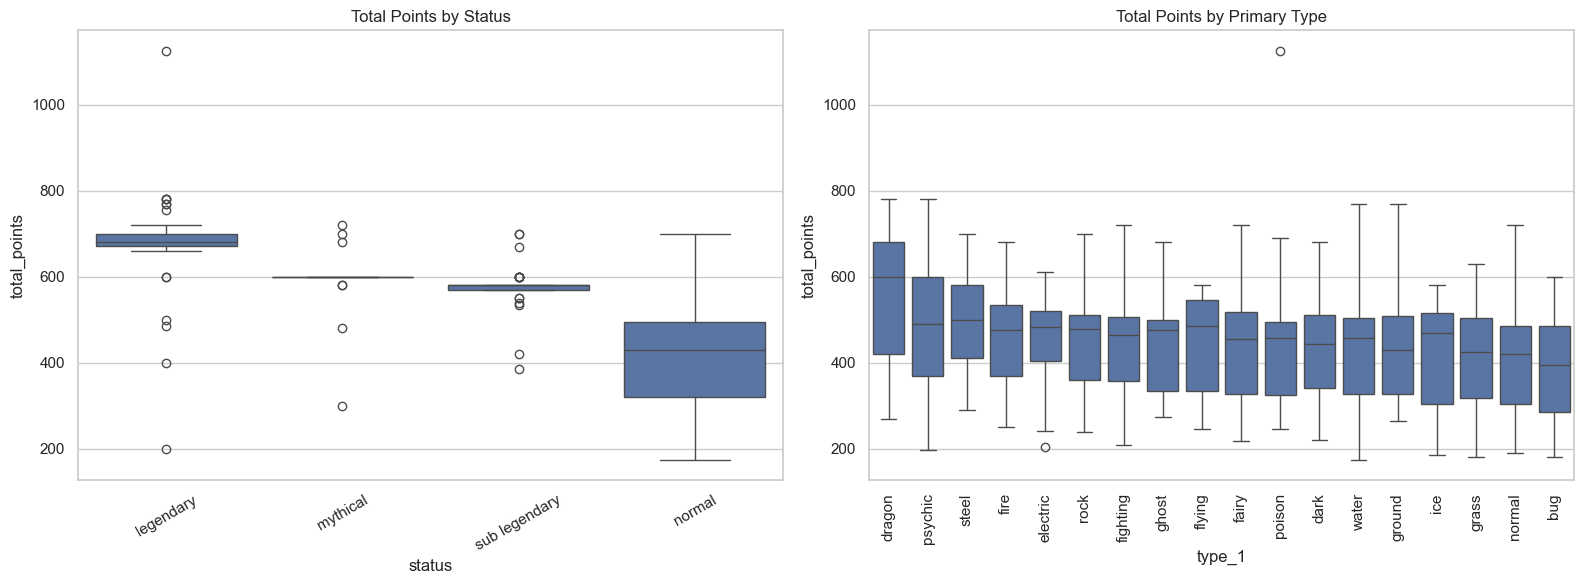

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_order = pokemon_clean.groupby("status")["total_points"].mean().sort_values(ascending=False).index
sns.boxplot(data=pokemon_clean, x="status", y="total_points", order=status_order, ax=axes[0])
axes[0].set_title("Total Points by Status")
axes[0].tick_params(axis="x", rotation=30)

type_order = pokemon_clean.groupby("type_1")["total_points"].mean().sort_values(ascending=False).index
sns.boxplot(data=pokemon_clean, x="type_1", y="total_points", order=type_order, ax=axes[1])
axes[1].set_title("Total Points by Primary Type")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()

In [14]:
growth_summary = (
    pokemon_clean.groupby("growth_rate")["total_points"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
growth_summary

,count,mean,median
growth_rate,,,
slow,256,532.980469,570.0
medium slow,245,416.710204,405.0
erratic,26,411.576923,457.0
medium fast,436,407.589450,435.0
fluctuating,14,403.214286,444.0
fast,68,390.176471,410.0


## Encoded Feature Inspection

In [15]:
encoded_corr = pokemon_features.corr(numeric_only=True)["total_points"].sort_values(key=lambda s: s.abs(), ascending=False)
encoded_corr.head(15)

total_points               1.000000
log_weight_kg              0.613764
status_normal             -0.531154
growth_rate_slow           0.437379
height_m                   0.374311
status_sub legendary       0.265161
growth_rate_medium fast   -0.220414
status_mythical            0.218983
type_2_none               -0.212363
type_1_dragon              0.160778
type_2_dragon              0.153310
type_2_fighting            0.119010
type_1_psychic             0.118904
growth_rate_fast          -0.106399
growth_rate_medium slow   -0.102765
Name: total_points, dtype: float64

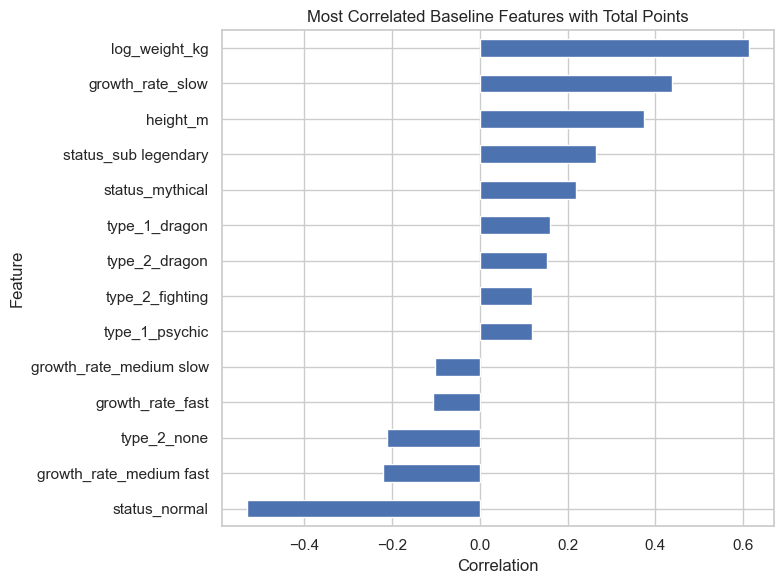

In [16]:
encoded_corr.head(15).drop("total_points").sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Most Correlated Baseline Features with Total Points")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()